# ***Importing Libraries***

In [ ]:
print(1)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
print("All libraries are working!")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import BaggingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df1 = pd.read_csv("/content/exercise.csv")
df2 = pd.read_csv("/content/calories.csv")
df = pd.concat([df1,df2],axis=1)

# ***Exploratory Data Analysis (EDA)***

In [ ]:
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,User_ID,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,14733363,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,14861698,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,11179863,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,16180408,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,17771927,35.0


In [ ]:
df.shape


(15000, 10)

In [ ]:
df.dtypes

,0
User_ID,int64
Gender,object
Age,int64
Height,float64
Weight,float64
Duration,float64
Heart_Rate,float64
Body_Temp,float64
User_ID,int64
Calories,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   User_ID     15000 non-null  int64  
 9   Calories    15000 non-null  float64
dtypes: float64(6), int64(3), object(1)
memory usage: 1.1+ MB


In [ ]:
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,User_ID,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,1.500000e+04,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,1.497736e+07,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,2.872851e+06,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000116e+07,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,1.247419e+07,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,1.499728e+07,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,1.744928e+07,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,1.999965e+07,314.000000


In [ ]:
df["Gender"].describe()

,Gender
count,15000
unique,2
top,female
freq,7553


In [ ]:
df.drop("User_ID",axis=1,inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.isna().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
Duration,0
Heart_Rate,0
Body_Temp,0
Calories,0


In [ ]:
df["Gender"].value_counts()

,count
Gender,
female,7552
male,7447


In [ ]:
numeric_df = df.select_dtypes(include="number")

# *Data Visaulization*

<Axes: xlabel='Gender', ylabel='count'>

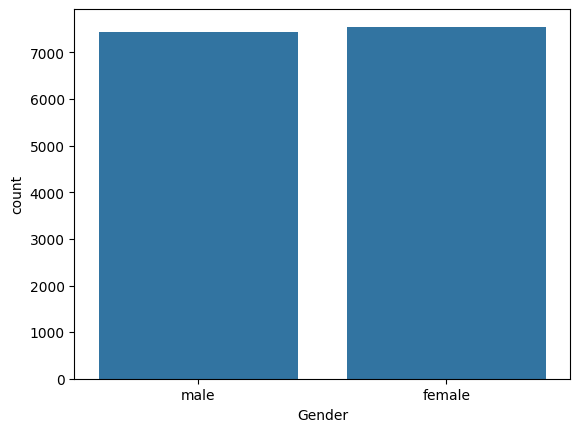

In [ ]:
sns.countplot(x=df["Gender"])

<Axes: >

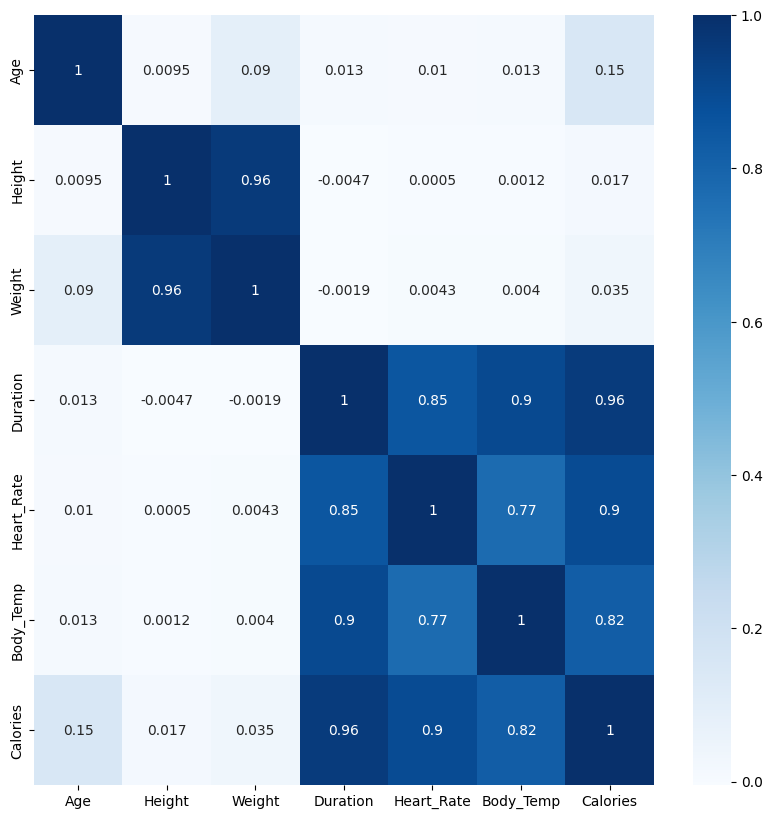

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(numeric_df.corr(),annot=True,cmap="Blues")

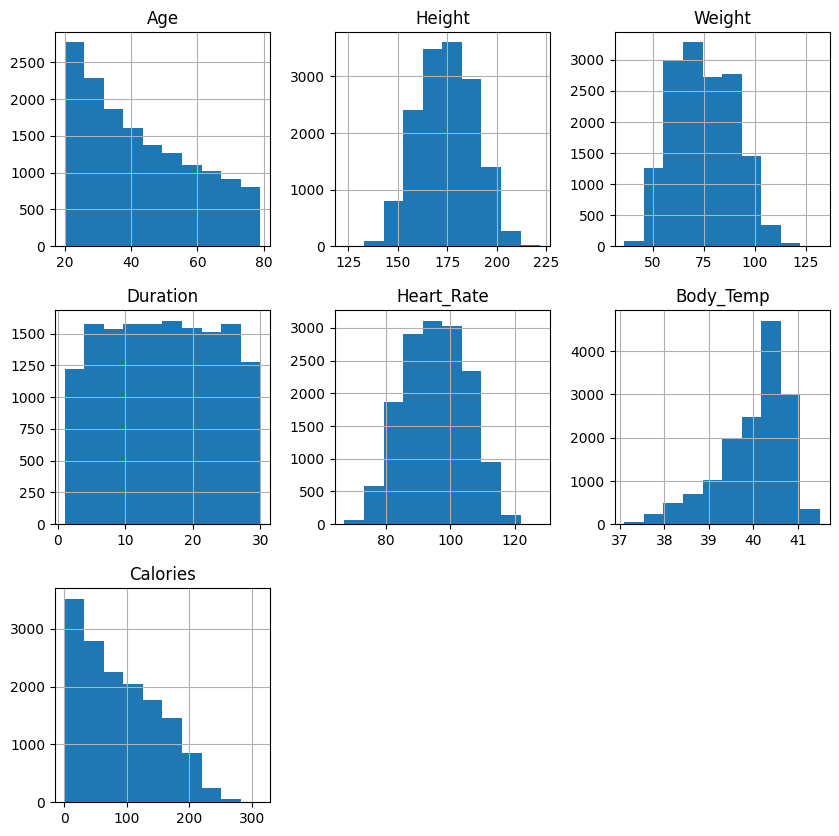

In [ ]:
df.hist(figsize=(10,10))
plt.show()

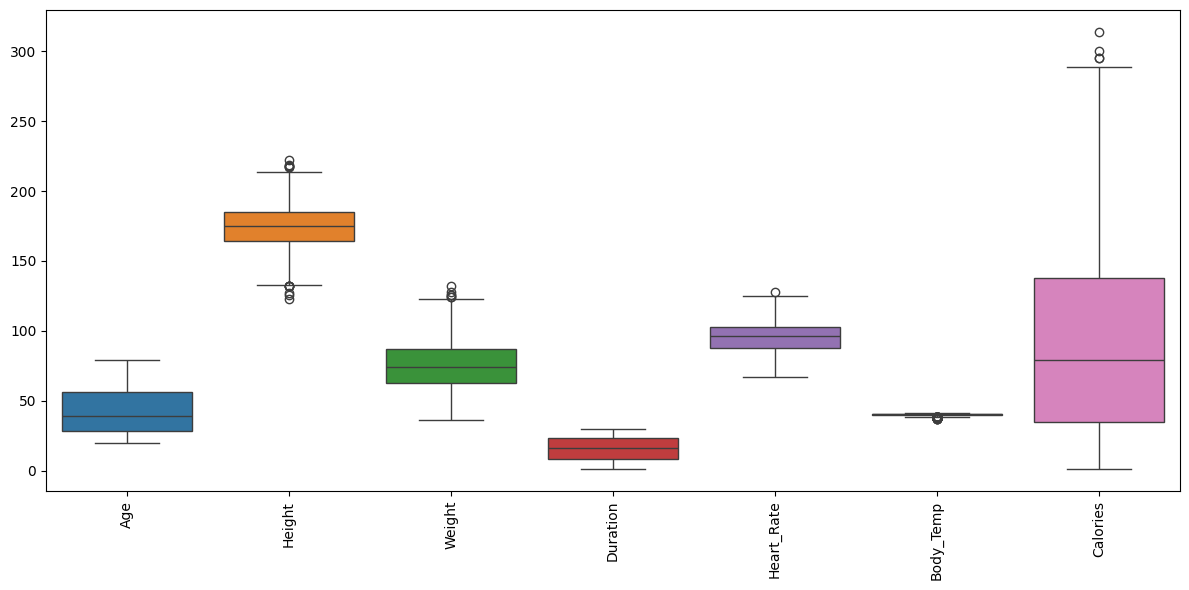

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df.select_dtypes(include='number'))

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

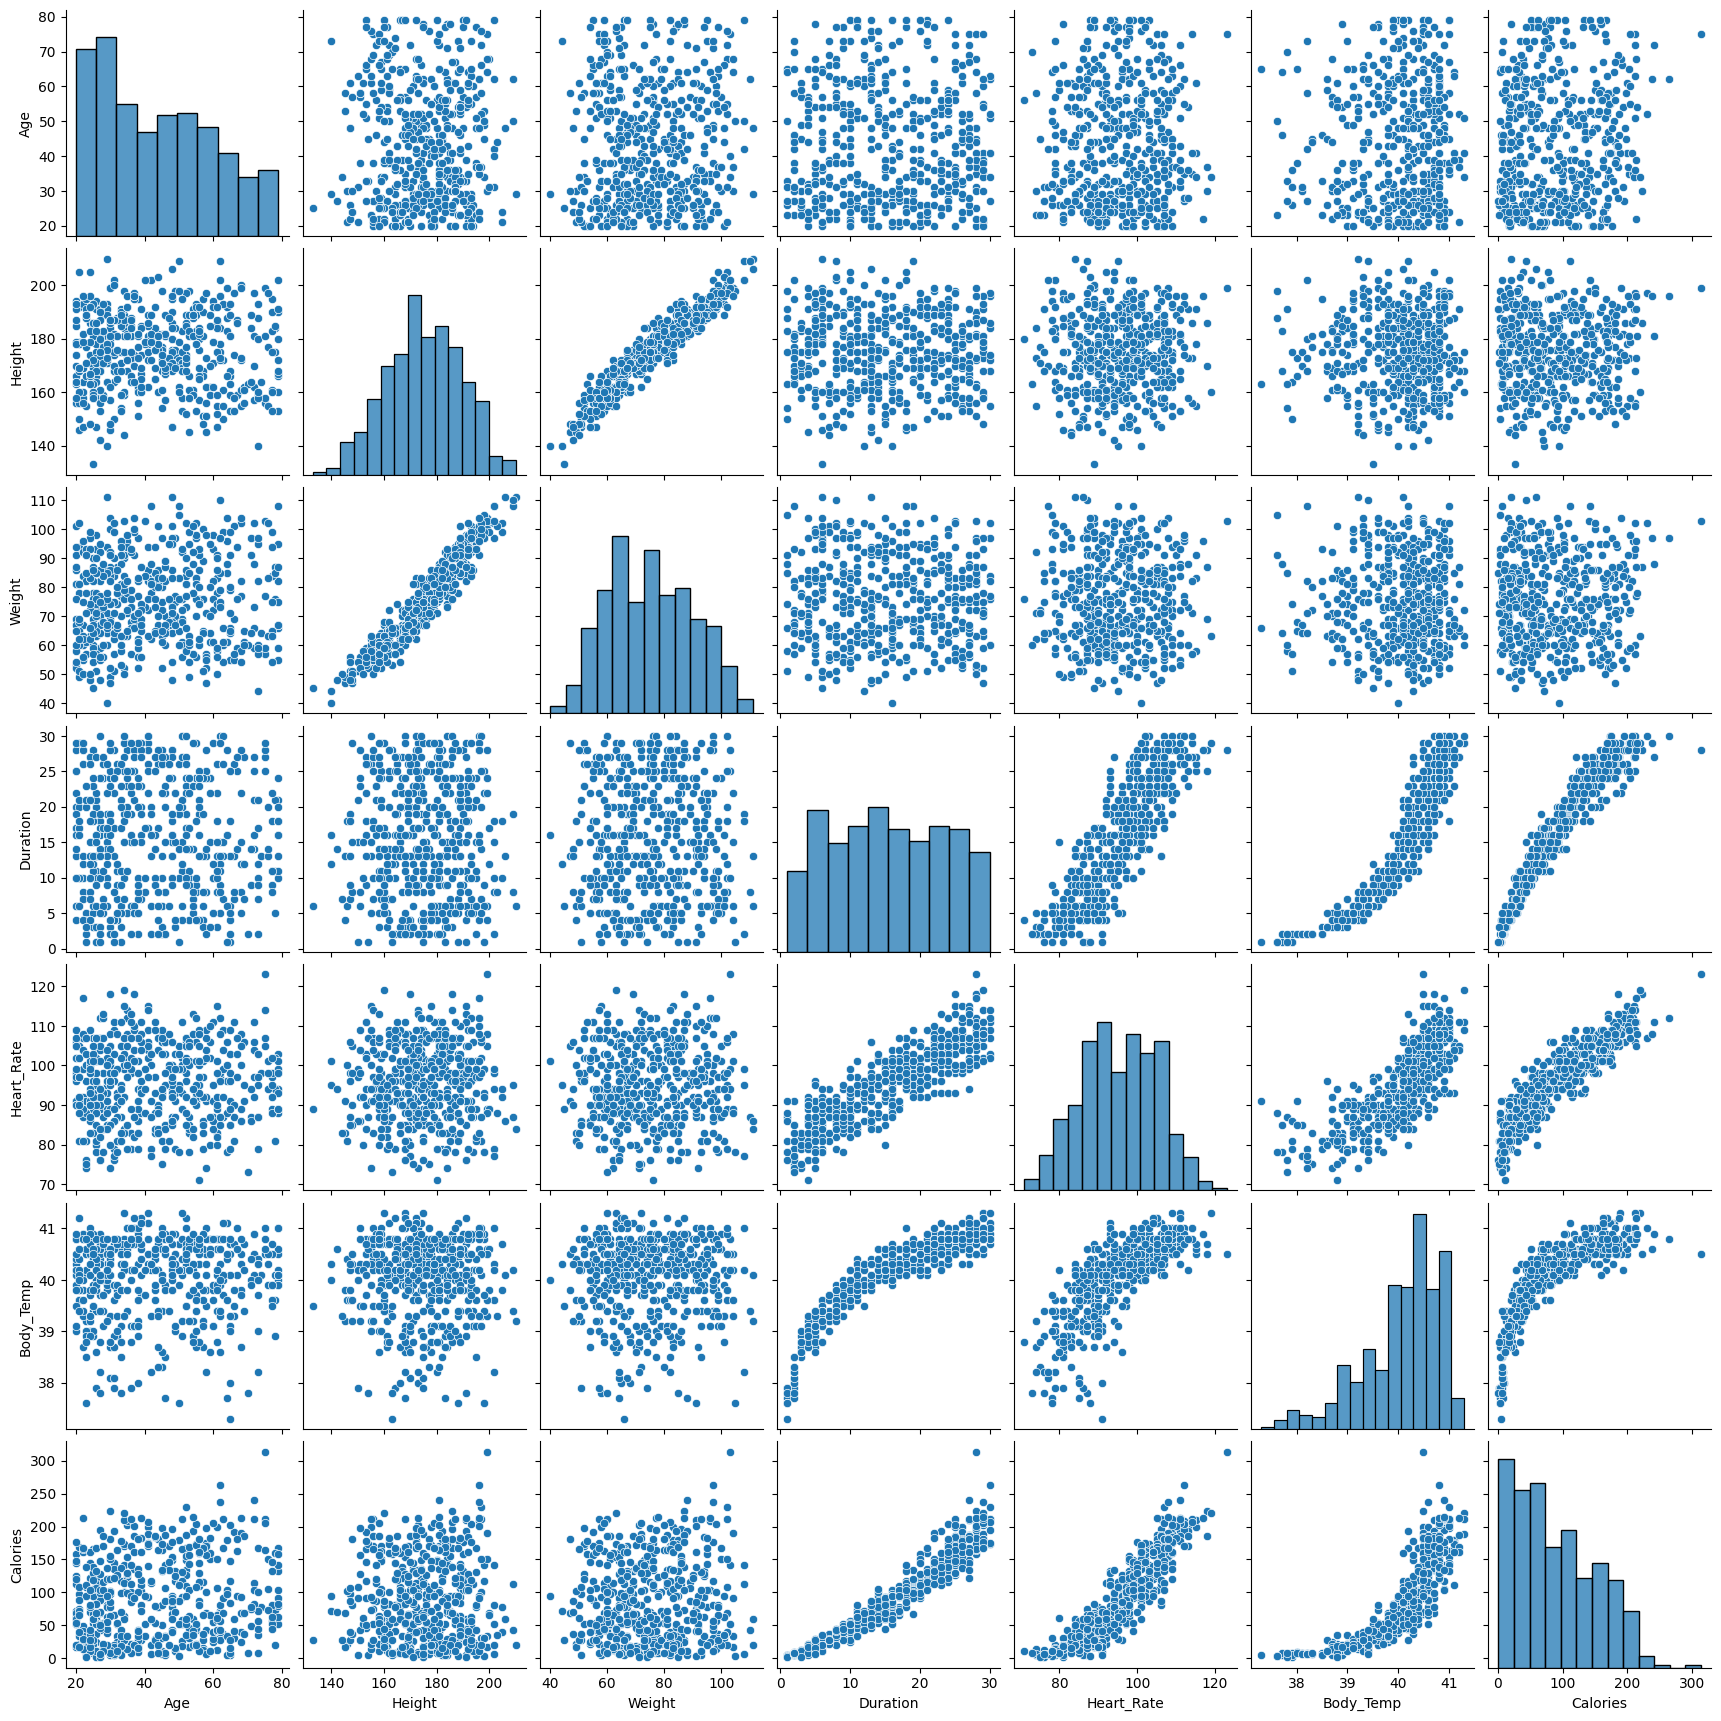

In [ ]:
sns.pairplot(numeric_df.sample(500))

<Axes: >

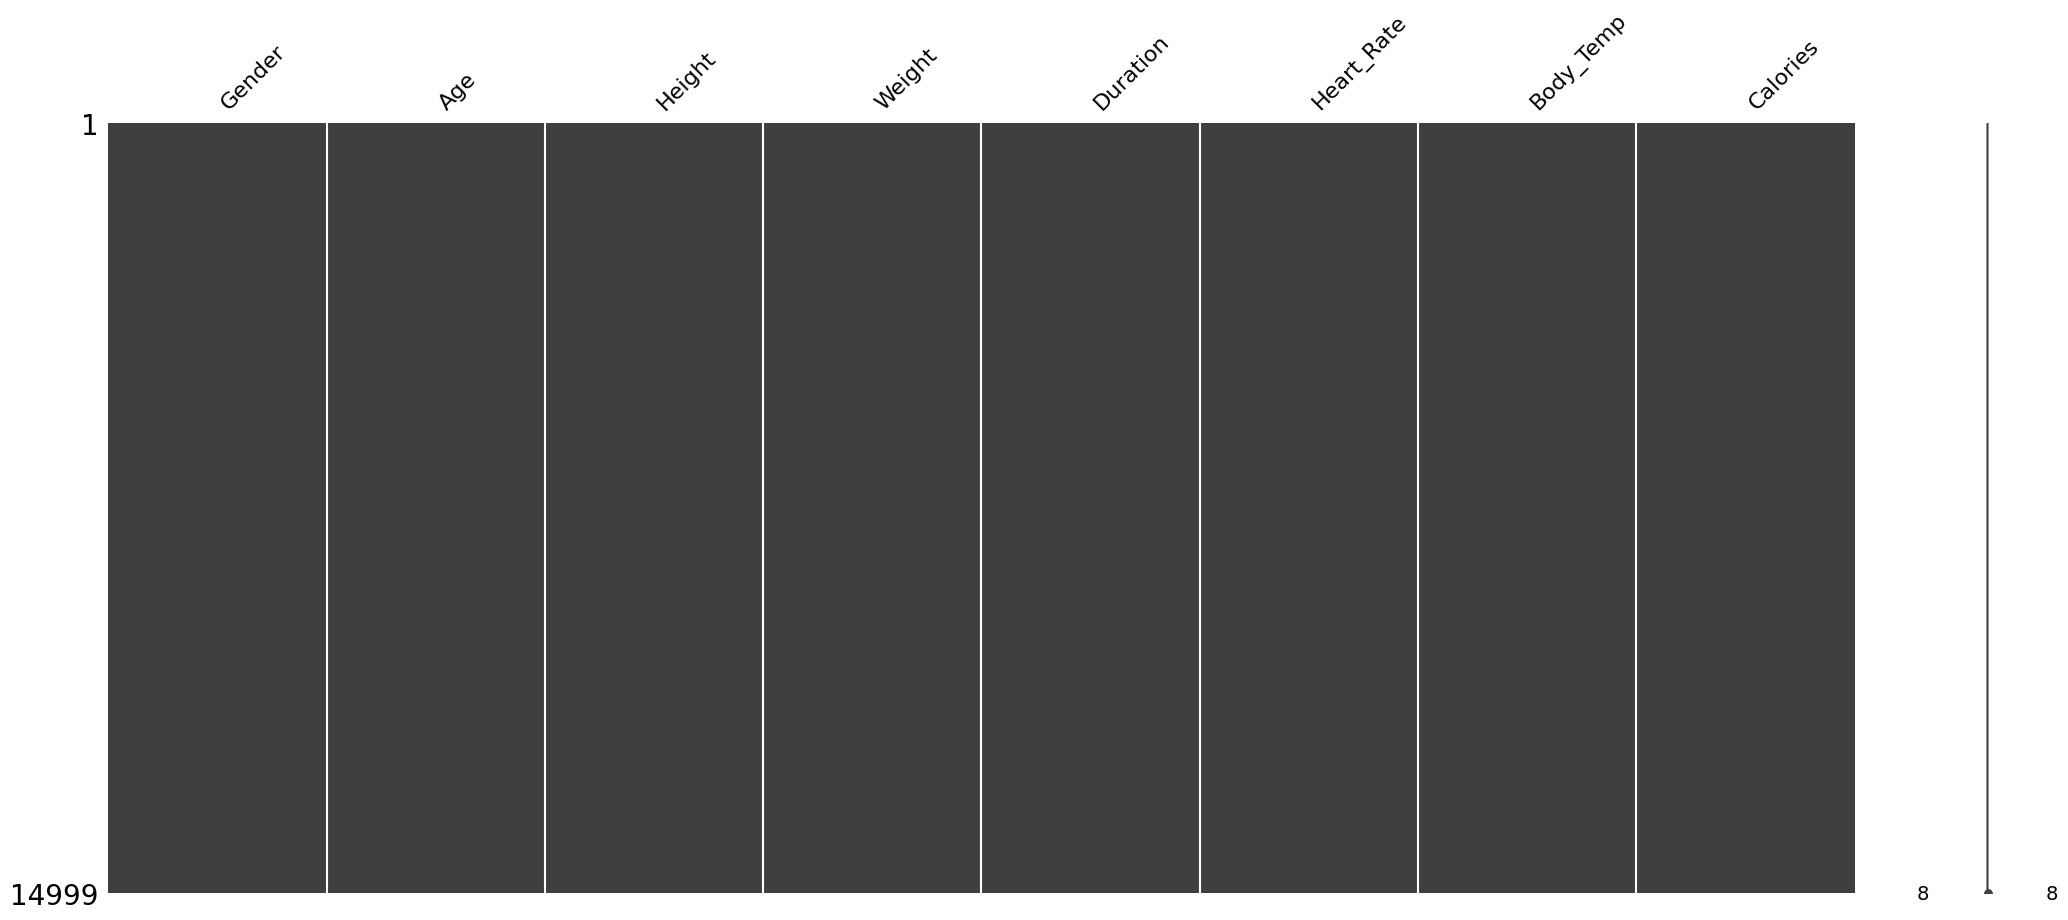

In [ ]:
import missingno as msno
msno.matrix(df)

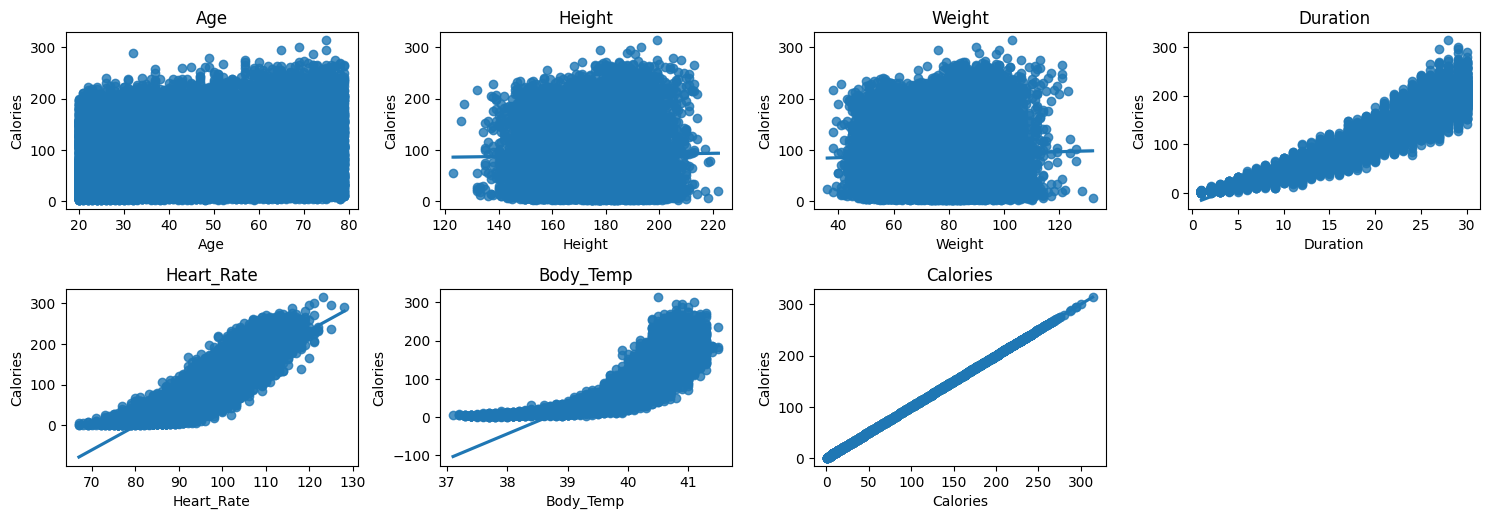

In [ ]:
num_cols = df.select_dtypes(include="number").columns

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i+1)
    sns.regplot(x=df[col], y=df["Calories"])
    plt.title(col)
plt.tight_layout()
plt.show()

# ***Data Preprocessing***

In [ ]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)


In [ ]:
df["Gender"]=df["Gender"].map({"male":1,"female":0})

In [ ]:
X = df.drop("Calories",axis=1)
y = df["Calories"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
models = {
    "LinearRegression": (
        LinearRegression(),
        {}
    ),

    "Lasso": (
        Lasso(),
        {"alpha": [0.01, 0.1, 1, 10]}
    ),

    "Ridge": (
        Ridge(),
        {"alpha": [0.01, 0.1, 1, 10]}
    ),

    "KNN": (
        KNeighborsRegressor(),
        {"n_neighbors": [3,5,7,9]}
    ),

    "DecisionTree": (
        DecisionTreeRegressor(random_state=42),
        {"max_depth": [None, 5,10,20]}
    ),

    "RandomForest": (
        RandomForestRegressor(random_state=42),
        {"n_estimators": [100,200],
         "max_depth": [None,10,20]}
    ),

    "GradientBoosting": (
        GradientBoostingRegressor(random_state=42),
        {"n_estimators": [100,200],
         "learning_rate": [0.01,0.1],
         "max_depth": [3,5]}
    ),

    "AdaBoost": (
        AdaBoostRegressor(random_state=42),
        {"n_estimators": [50,100],
         "learning_rate": [0.01,0.1,1]}
    ),

    "Bagging": (
        BaggingRegressor(random_state=42),
        {"n_estimators": [10,50,100]}
    ),

    "XGBoost": (
        XGBRegressor(random_state=42),
        {"n_estimators": [100,200],
         "learning_rate": [0.01,0.1],
         "max_depth": [3,5]}
    )
}

results = []


In [ ]:
for name, (model, params) in models.items():

    grid = GridSearchCV(
        model,
        params,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_


    y_train_pred = best_model.predict(X_train)
    y_test_pred  = best_model.predict(X_test)


    train_r2 = r2_score(y_train, y_train_pred)
    test_r2  = r2_score(y_test, y_test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse  = np.sqrt(mean_squared_error(y_test, y_test_pred))

    results.append([
        name,
        train_r2,
        test_r2,
        train_rmse,
        test_rmse,
        grid.best_params_
    ])


In [ ]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Train R2",
        "Test R2",
        "Train RMSE",
        "Test RMSE",
        "Best Params"
    ]
)

results_df.sort_values(by="Test R2", ascending=False)

,Model,Train R2,Test R2,Train RMSE,Test RMSE,Best Params
6,GradientBoosting,0.999586,0.999319,1.271187,1.623435,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti..."
9,XGBoost,0.999559,0.999229,1.313043,1.727578,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti..."
5,RandomForest,0.999719,0.997905,1.048517,2.848157,"{'max_depth': 20, 'n_estimators': 200}"
8,Bagging,0.999701,0.997815,1.079874,2.909124,{'n_estimators': 100}
3,KNN,0.994969,0.993369,4.433041,5.067735,{'n_neighbors': 9}
4,DecisionTree,1.000000,0.991946,0.000000,5.584950,{'max_depth': None}
7,AdaBoost,0.968221,0.968071,11.141341,11.119881,"{'learning_rate': 1, 'n_estimators': 100}"
1,Lasso,0.967392,0.966167,11.285812,11.446658,{'alpha': 0.01}
2,Ridge,0.967394,0.966154,11.285369,11.448935,{'alpha': 0.01}
0,LinearRegression,0.967394,0.966154,11.285369,11.448936,{}


In [ ]:
best_model = GradientBoostingRegressor

In [ ]:
best_model = best_model(
    learning_rate = 0.1,
    max_depth = 5,
    n_estimators = 200
)
best_model.fit(X_train, y_train)

GradientBoostingRegressor(max_depth=5, n_estimators=200)

In [ ]:
import joblib
joblib.dump(best_model, 'model.joblib')
joblib.dump(scaler, 'scaler.joblib')

['scaler.joblib']